<a href="https://colab.research.google.com/github/haeozo/Data/blob/main/notebooks/02_colab_overview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Работа с данными в Google Colab

In [37]:
import sys

print("Версия Python:", sys.version)

Версия Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


### Проверка версии Python

В локальной среде разработки используется Python 3.12.14, что соответствует требованиям.

В Google Colab в используется Python 3.13.15. Это связано с тем, что Colab предоставляет собственную среду выполнения.

In [38]:
!pip install pandas polars

In [2]:
import pandas as pd
import polars as p1

print("Версия pandas:",pd.__version__)
print("Версия polars:",p1.__version__)

Версия pandas: 2.2.3
Версия polars: 1.35.2


## Установка библиотек
Для работы с табличными данными устанавливаются библиотеки pandas и polars.

После установки выводятся их версии.

## Загрузка отладочного среза

Для анализа используется отладочный срез исходного набора данных.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving top_podcasts_debug.csv to top_podcasts_debug (5).csv


In [3]:
import pandas as pd

df = pd.read_csv("top_podcasts_debug (5).csv")

## Структура данных

После чтения отладочного среза выводится количество строк и столбцов, названия столбцов и типы содержащихся в них данных.

In [4]:
print(f"Число строк: {df.shape[0]}")
print(f"Число столбцов: {df.shape[1]}")

Число строк: 199999
Число столбцов: 16


In [5]:
df.dtypes.to_frame("Тип данных")
print(df.dtypes)

date                    object
rank                     int64
region                  object
chartRankMove           object
episodeUri              object
showUri                 object
episodeName             object
description             object
show.name               object
show.publisher          object
duration_ms            float64
explicit                  bool
languages               object
release_date            object
show.media_type         object
show.total_episodes    float64
dtype: object


## Анализ пропущенных значений

Для каждого столбца рассчитывается доля пропущенных значений относительно общего количества записей.

In [9]:
missing_percent = df.isna().mean() * 100

missing_percent.to_frame("Доля пропусков, %")

,"Доля пропусков, %"
date,0.000000
rank,0.000000
region,0.000000
chartRankMove,0.000000
episodeUri,0.000000
showUri,0.000000
episodeName,0.000000
description,1.152006
show.name,0.000000
show.publisher,0.000000


## Визуализация данных

В качестве примера выбрано распределение продолжительности эпизодов подкастов.
Столбец `duration_ms` содержит продолжительность эпизода в миллисекундах.
Для наглядности значения преобразуются в минуты.

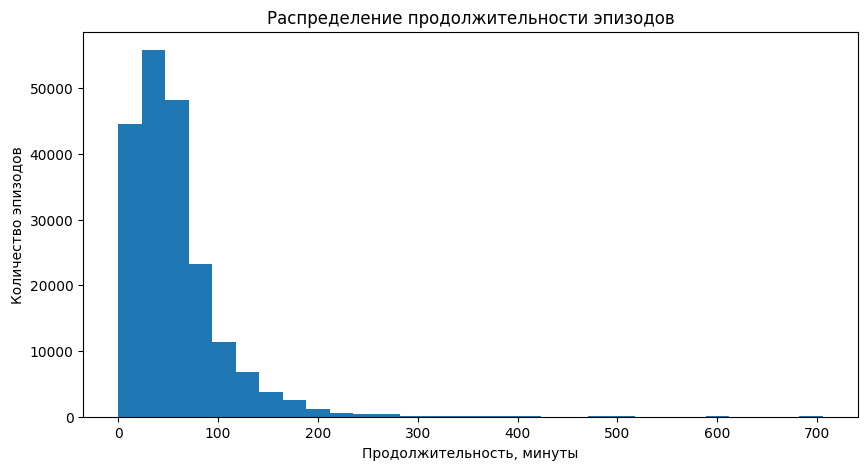

In [11]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

duration_minutes = df["duration_ms"] / 60_000

plt.figure(figsize=(10, 5))
plt.hist(duration_minutes, bins=30)

plt.title("Распределение продолжительности эпизодов")
plt.xlabel("Продолжительность, минуты")
plt.ylabel("Количество эпизодов")

plt.show()